In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\MOHINI\Downloads\European_Bank (1).csv")





In [7]:
# Re-apply engagement profiles (same function as Phase 3)
def classify_engagement(row):
    active = row['IsActiveMember'] == 1
    multi_product = row['NumOfProducts'] > 1
    high_balance = row['Balance'] > df['Balance'].median()
    if active and multi_product:
        return 'Active Engaged'
    elif active and not multi_product:
        return 'Active Low-Product'
    elif not active and high_balance:
        return 'Inactive High-Balance'
    else:
        return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)

   NumOfProducts  ChurnRate
0              1      27.71
1              2       7.58
2              3      82.71
3              4     100.00


C:\Users\MOHINI\AppData\Local\Temp\ipykernel_2244\2551487239.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_products, x='NumOfProducts', y='ChurnRate', palette='Blues_r')


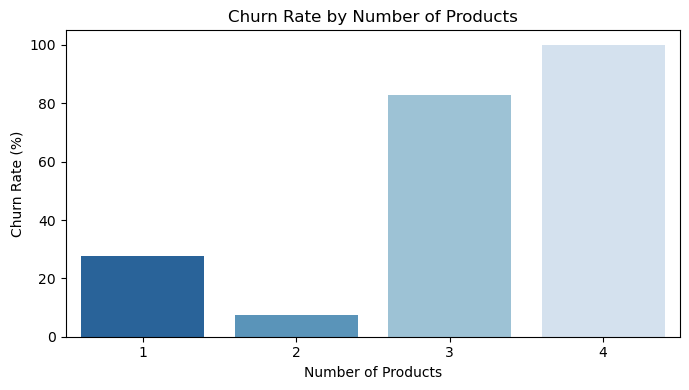

In [9]:
# ── Churn Rate by Number of Products ─────────────────────
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean().reset_index()
churn_by_products.columns = ['NumOfProducts', 'ChurnRate']
churn_by_products['ChurnRate'] = (churn_by_products['ChurnRate'] * 100).round(2)
print(churn_by_products)

plt.figure(figsize=(7, 4))
sns.barplot(data=churn_by_products, x='NumOfProducts', y='ChurnRate', palette='Blues_r')
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Number of Products')
plt.tight_layout()
plt.savefig('churn_by_products.png', dpi=150)
plt.show()

In [10]:
# ── Single vs Multi Product Retention ────────────────────
df['ProductDepth'] = df['NumOfProducts'].apply(lambda x: 'Single' if x == 1 else 'Multi')
churn_depth = df.groupby('ProductDepth')['Exited'].mean().reset_index()
print(churn_depth)

  ProductDepth    Exited
0        Multi  0.127746
1       Single  0.277144


In [11]:
# ── KPI: Product Depth Index ──────────────────────────────
# Ratio of multi-product customers who stayed vs single-product who stayed
multi_retained = df[(df['ProductDepth'] == 'Multi') & (df['Exited'] == 0)].shape[0]
single_retained = df[(df['ProductDepth'] == 'Single') & (df['Exited'] == 0)].shape[0]
product_depth_index = round(multi_retained / single_retained, 4)
print(f"\nProduct Depth Index: {product_depth_index}")


Product Depth Index: 1.1668


In [12]:
# ── Balance vs Activity ───────────────────────────────────
balance_activity = df.groupby('IsActiveMember').agg(
    AvgBalance=('Balance', 'mean'),
    ChurnRate=('Exited', 'mean')
).reset_index()
print(balance_activity)

   IsActiveMember    AvgBalance  ChurnRate
0               0  77134.376863   0.268509
1               1  75875.422145   0.142691


In [13]:
# ── At-Risk Premium Customers ─────────────────────────────
# High balance + inactive + churned
high_balance_threshold = df['Balance'].quantile(0.75)

at_risk = df[
    (df['Balance'] >= high_balance_threshold) &
    (df['IsActiveMember'] == 0)
].copy()

at_risk_churn_rate = at_risk['Exited'].mean() * 100
print(f"\nAt-Risk Premium Customer Count: {len(at_risk)}")
print(f"Their Churn Rate: {at_risk_churn_rate:.2f}%")


At-Risk Premium Customer Count: 1247
Their Churn Rate: 30.47%


In [14]:
# ── KPI: High-Balance Disengagement Rate ──────────────────
high_balance_disengagement_rate = round(
    df[(df['Balance'] >= high_balance_threshold) & (df['IsActiveMember'] == 0)].shape[0] /
    df[df['Balance'] >= high_balance_threshold].shape[0] * 100, 2
)
print(f"High-Balance Disengagement Rate: {high_balance_disengagement_rate}%")


High-Balance Disengagement Rate: 49.88%


In [15]:
# ── Salary-Balance Mismatch ───────────────────────────────
df['SalaryBalanceRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
mismatch = df[df['SalaryBalanceRatio'] < 0.1]  # Low balance despite salary
print(f"\nSalary-Balance Mismatch Count (low depositors): {len(mismatch)}")


Salary-Balance Mismatch Count (low depositors): 3619


In [16]:
# ── KPI 1: Engagement Retention Ratio ────────────────────
active_churn = df[df['IsActiveMember'] == 1]['Exited'].mean()
inactive_churn = df[df['IsActiveMember'] == 0]['Exited'].mean()
engagement_retention_ratio = round(inactive_churn / active_churn, 4)
print(f"Engagement Retention Ratio: {engagement_retention_ratio}")


Engagement Retention Ratio: 1.8818


In [17]:
# ── KPI 2: Product Depth Index (already computed above) ──
print(f"Product Depth Index: {product_depth_index}")

Product Depth Index: 1.1668


In [18]:
# ── KPI 3: High-Balance Disengagement Rate ────────────────
print(f"High-Balance Disengagement Rate: {high_balance_disengagement_rate}%")


High-Balance Disengagement Rate: 49.88%


In [19]:
# ── KPI 4: Credit Card Stickiness Score ──────────────────
card_churn = df[df['HasCrCard'] == 1]['Exited'].mean()
no_card_churn = df[df['HasCrCard'] == 0]['Exited'].mean()
cc_stickiness = round(no_card_churn / card_churn, 4)
print(f"Credit Card Stickiness Score: {cc_stickiness}")

Credit Card Stickiness Score: 1.0312


In [20]:
# ── KPI 5: Relationship Strength Index ───────────────────
df['RSI'] = (
    df['IsActiveMember'] * 0.4 +
    (df['NumOfProducts'] / df['NumOfProducts'].max()) * 0.4 +
    (df['HasCrCard'] * 0.2)
)
print(f"\nRelationship Strength Index Stats:")
print(df['RSI'].describe())


Relationship Strength Index Stats:
count    10000.000000
mean         0.500160
std          0.226908
min          0.100000
25%          0.300000
50%          0.500000
75%          0.700000
max          1.000000
Name: RSI, dtype: float64
